**DAY 01 & 02 – Dataset Understanding (Fake News Detection)**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving fake_news_dataset.csv to fake_news_dataset.csv


In [2]:
import pandas as pd

df = pd.read_csv("fake_news_dataset.csv")
df.head()

,title,text,date,source,author,category,label
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake


In [3]:
df.shape

(20000, 7)

In [4]:
df.columns

Index(['title', 'text', 'date', 'source', 'author', 'category', 'label'], dtype='object')

In [5]:
df.isnull().sum()

,0
title,0
text,0
date,0
source,1000
author,1000
category,0
label,0


In [6]:
df['label'].value_counts()

,count
label,
fake,10056
real,9944


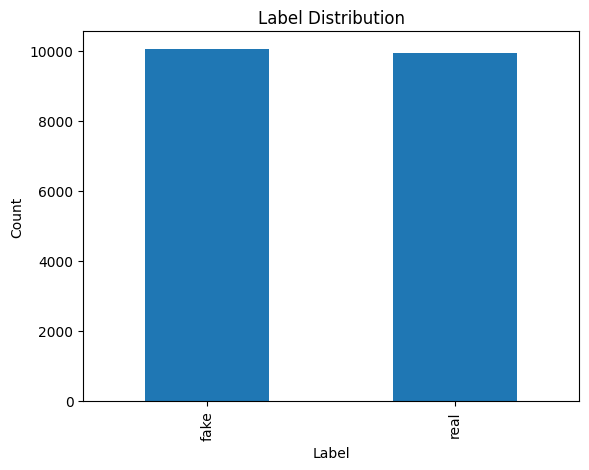

In [7]:
# bar chart
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [8]:
df.sample(5)

,title,text,date,source,author,category,label
17348,Boy so manager prevent never performance least.,condition religious system her car effect feel...,2022-09-02,BBC,Brad Smith,Technology,real
4385,Idea election common the music machine.,lose program technology room yes box role avai...,2023-03-11,The Guardian,Martha Robinson,Health,real
13729,Table outside store rich he hold technology be...,value difficult cause poor security listen lik...,2024-07-14,BBC,Norma Mitchell,Technology,real
2671,Traditional purpose social.,necessary try account six ground threat win me...,2022-06-13,The Guardian,Ashlee Weber,Politics,real
3421,Thank once because magazine lawyer oil pressur...,leader standard low day approach example alone...,2025-01-27,Reuters,Mario Harding,Entertainment,fake


**Dataset Summary**

The dataset contains 20,000 news articles and 7 columns: title, text, date, source, author, category, and label.

The label column represents whether the news is fake or real.

Label distribution:

Fake news: 10056

Real news: 9944

Since both classes have nearly equal samples, the dataset is balanced.

Missing values exist in the source and author columns, but since these columns are not required for model training, no cleaning was necessary.

Five sample entries from the dataset were also displayed to understand the structure of the data.

**Day 03 - Tokenization & Data Preparation**

In [9]:
df["content"] = df["title"] + " " + df["text"]
df[["content","label"]].head()

,content,label
0,Foreign Democrat final. more tax development b...,real
1,To offer down resource great point. probably g...,fake
2,Himself church myself carry. them identify for...,fake
3,You unit its should. phone which item yard Rep...,fake
4,Billion believe employee summer how. wonder my...,fake


In [10]:
df["label"] = df["label"].map({"fake":0, "real":1})
df[["content","label"]].head()

,content,label
0,Foreign Democrat final. more tax development b...,1
1,To offer down resource great point. probably g...,0
2,Himself church myself carry. them identify for...,0
3,You unit its should. phone which item yard Rep...,0
4,Billion believe employee summer how. wonder my...,0


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["content"],
    df["label"],
    test_size=0.2,
    random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 16000
Test size: 4000


In [12]:
!pip install transformers

In [13]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [14]:
sample_text = X_train.iloc[0]

tokens = tokenizer(
    sample_text,
    padding="max_length",
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

print(tokens)

{'input_ids': tensor([[  101,  2287,  2590,  7155,  3160,  2339,  3031,  4023,  1012,  3746,
          2851,  3251,  2245,  2698,  2436,  3829,  2067,  3056,  2444,  2064,
          2702,  4496,  3497,  3786,  2274,  2250,  4685,  2092,  2426,  2167,
          7325,  7823,  4608,  2313,  3447,  2317,  2501,  4608,  4507,  2715,
          2894,  2617,  2309,  2744,  3392,  2283,  4287,  1998,  2000,  2684,
          3514,  2092,  2004,  4366,  2408,  3399,  2381,  2149,  3116,  6592,
          2082,  2707,  2738,  3168,  2045,  2593,  3361,  2041,  2455,  2364,
          3447,  2192,  2974,  2898,  2283,  2037,  3716,  3465,  3046,  2664,
          2036,  3806,  3026,  5587,  2932,  2395,  2604,  2613,  4639,  2611,
          3649,  2342,  2312,  2612,  2311,  5769,  2369,  2064,  2034,  3749,
          2326,  2028,  3599,  2367,  3154,  4595,  3112,  4031,  3298,  8013,
          3233,  2562,  5333,  3942,  2256,  2718,  3147,  5466,  2430,  3800,
          2379,  2492,  3185,  2274,  

In [15]:
print(tokens["input_ids"].shape)
print(tokens["attention_mask"].shape)

torch.Size([1, 128])
torch.Size([1, 128])


**Tokenization & Data Preparation Summary**

The dataset was prepared for model training.

First, a new column called **content** was created by combining the **title** and **text** columns. This helped in using both headline and article body as input for the model.

Next, the **label column** was converted into numerical format. The label **fake** was mapped to **0** and **real** was mapped to **1**, making it suitable for machine learning algorithms.

Finally, the dataset was split into **training and testing sets** using the `train_test_split` function from Scikit-learn.  
80% of the data was used for training and 20% was used for testing.

Training set size: **16,000 samples**  
Testing set size: **4,000 samples**

The dataset was further prepared for use in a transformer-based model.

First, the required NLP library **Transformers** was installed and imported. Then, the **BERT tokenizer (bert-base-uncased)** was loaded using the Hugging Face Transformers library.

The tokenizer was used to convert text into numerical tokens that the model can understand. A sample text from the dataset was tokenized to observe how the tokenizer converts words into token IDs.

During tokenization, parameters such as **padding**, **truncation**, and **maximum sequence length (128)** were applied to ensure that all input sequences have the same length and can be processed efficiently by the model.

The output tokens, including **input IDs**, **attention masks**, and **token type IDs**, were displayed to understand the structure of the encoded text before feeding it into the model.

**Day 04 & 05 - Model Fine-Tuning**

In [16]:
import torch
torch.cuda.is_available()

True

In [17]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [18]:
train_encodings = tokenizer(
    list(X_train),
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

test_encodings = tokenizer(
    list(X_test),
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

In [19]:
import torch

train_labels = torch.tensor(y_train.values)
test_labels = torch.tensor(y_test.values)

In [20]:
class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

In [21]:
train_dataset = NewsDataset(train_encodings, train_labels)
test_dataset = NewsDataset(test_encodings, test_labels)

In [22]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir="./logs"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [23]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [24]:
trainer.train()

Step,Training Loss
500,0.709412
1000,0.703693
1500,0.703443
2000,0.702103
2500,0.699590
3000,0.699840
3500,0.698313
4000,0.697194


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4000, training_loss=0.7016985931396484, metrics={'train_runtime': 967.971, 'train_samples_per_second': 33.059, 'train_steps_per_second': 4.132, 'total_flos': 2104888442880000.0, 'train_loss': 0.7016985931396484, 'epoch': 2.0})

In [25]:
trainer.evaluate()

{'eval_loss': 0.6932011246681213,
 'eval_runtime': 31.7378,
 'eval_samples_per_second': 126.033,
 'eval_steps_per_second': 15.754,
 'epoch': 2.0}

In [26]:
trainer.save_model("fake_news_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [27]:
from sklearn.metrics import accuracy_score
import numpy as np

predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)

accuracy = accuracy_score(y_test, preds)
print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.50725


**Model Fine-Tuning Summary**

A pretrained BERT model (bert-base-uncased) was loaded for sequence classification with two labels: fake and real.

The model was fine-tuned on the prepared dataset for 2 epochs using the Hugging Face Trainer API. During training, the model processed the dataset in batches and the training loss was monitored at different steps.

After training, the model was evaluated on the test dataset to measure its performance. The evaluation produced a validation loss and accuracy score.

Results:

Training Loss: 0.7015

Validation Loss: 0.6931

Validation Accuracy: 50.7%

Finally, the trained model was saved locally for future use.

**Day 06 - Evaluation**

In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)

In [30]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.51      1.00      0.67      2029
           1       0.00      0.00      0.00      1971

    accuracy                           0.51      4000
   macro avg       0.25      0.50      0.34      4000
weighted avg       0.26      0.51      0.34      4000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


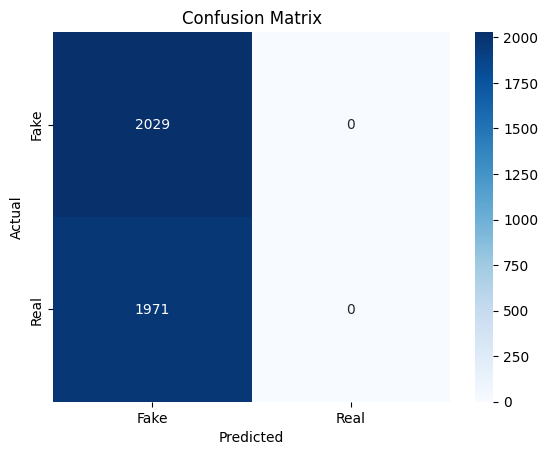

In [31]:
cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Fake","Real"],
            yticklabels=["Fake","Real"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Model Evaluation Summary**

The trained BERT model was evaluated using standard classification metrics.

First, predictions were generated for the test dataset using the trained model. These predictions were compared with the true labels to compute performance metrics.

The following evaluation metrics were calculated:

- Accuracy
- Precision
- Recall
- F1-score

A classification report was generated to summarize these metrics for both fake and real news classes.

Additionally, a confusion matrix was created to visualize the model’s prediction performance. The confusion matrix shows the number of correct and incorrect predictions made by the model for each class.

These evaluation results help in understanding how well the model distinguishes between fake and real news articles.

**Day 07 - Error Analysis**

In [32]:
wrong_predictions = []

for i in range(len(preds)):
    if preds[i] != y_test.iloc[i]:
        wrong_predictions.append((X_test.iloc[i], y_test.iloc[i], preds[i]))

print("Total Wrong Predictions:", len(wrong_predictions))

Total Wrong Predictions: 1971


In [33]:
for i in range(5):
    text, actual, predicted = wrong_predictions[i]

    print("News:", text[:200])  # first 200 characters
    print("Actual Label:", actual)
    print("Predicted Label:", predicted)
    print("-"*80)

News: Society image vote these realize prevent can. better fall appear measure few prepare billion increase happy sit hot sure will since option a whose suddenly meet trade describe score people agreement s
Actual Label: 1
Predicted Label: 0
--------------------------------------------------------------------------------
News: Red offer dream again specific case. such east party truth place take tough stuff behind small method continue born eye happen billion magazine fast be join turn out someone serious character situatio
Actual Label: 1
Predicted Label: 0
--------------------------------------------------------------------------------
News: Behavior stop billion PM song own. better community begin town it case but operation story production half attack parent manage soon different wonder foot change next article particular owner vote sim
Actual Label: 1
Predicted Label: 0
--------------------------------------------------------------------------------
News: Only charge box time spen

In [34]:
label_map = {0:"Fake", 1:"Real"}

for i in range(5):
    text, actual, predicted = wrong_predictions[i]

    print("News:", text[:200])
    print("Actual:", label_map[actual])
    print("Predicted:", label_map[predicted])
    print("-"*80)

News: Society image vote these realize prevent can. better fall appear measure few prepare billion increase happy sit hot sure will since option a whose suddenly meet trade describe score people agreement s
Actual: Real
Predicted: Fake
--------------------------------------------------------------------------------
News: Red offer dream again specific case. such east party truth place take tough stuff behind small method continue born eye happen billion magazine fast be join turn out someone serious character situatio
Actual: Real
Predicted: Fake
--------------------------------------------------------------------------------
News: Behavior stop billion PM song own. better community begin town it case but operation story production half attack parent manage soon different wonder foot change next article particular owner vote sim
Actual: Real
Predicted: Fake
--------------------------------------------------------------------------------
News: Only charge box time spend want woman. care

**Error Analysis Summary**

Wrong predictions with explanation

In this step, the incorrect predictions made by the model were analyzed to understand the limitations of the trained classifier.

First, the predicted labels were compared with the true labels in the test dataset. Samples where the predicted label did not match the actual label were identified as misclassified examples. A total of 1971 incorrect predictions were found.

Several misclassified samples were inspected manually by displaying the news text along with the actual and predicted labels.

During the analysis, a clear pattern was observed. The model predicted most samples as **Fake**, even when the actual label was **Real**. This indicates that the model developed a bias toward one class during training.

Another reason for the misclassification is that the dataset contains synthetic or randomly generated sentences that do not resemble real news articles. Because the text lacks meaningful context and structure, the model struggles to learn meaningful patterns that distinguish fake news from real news.

Overall, the error analysis highlights the importance of using realistic datasets and balanced training strategies to improve model performance.

**Day 8: Model Improvement** (Compare DistilBERT vs BERT)

In [35]:
from transformers import DistilBertTokenizer

tokenizer_distil = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [36]:
train_encodings_d = tokenizer_distil(
    list(X_train),
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

test_encodings_d = tokenizer_distil(
    list(X_test),
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

In [37]:
train_dataset_d = NewsDataset(train_encodings_d, train_labels)
test_dataset_d = NewsDataset(test_encodings_d, test_labels)

In [38]:
from transformers import DistilBertForSequenceClassification

model_distil = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [39]:
trainer_distil = Trainer(
    model=model_distil,
    args=training_args,
    train_dataset=train_dataset_d,
    eval_dataset=test_dataset_d
)

trainer_distil.train()

Step,Training Loss
500,0.696814
1000,0.696289
1500,0.696245
2000,0.695150
2500,0.694728
3000,0.696777
3500,0.692566
4000,0.695169


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4000, training_loss=0.695467384338379, metrics={'train_runtime': 548.7528, 'train_samples_per_second': 58.314, 'train_steps_per_second': 7.289, 'total_flos': 1059739189248000.0, 'train_loss': 0.695467384338379, 'epoch': 2.0})

In [40]:
predictions_d = trainer_distil.predict(test_dataset_d)
preds_d = np.argmax(predictions_d.predictions, axis=1)

from sklearn.metrics import accuracy_score
accuracy_distil = accuracy_score(y_test, preds_d)

print("DistilBERT Accuracy:", accuracy_distil)

DistilBERT Accuracy: 0.50725


                                                      | Model      | Accuracy |
                                                      | ---------- | -------- |
                                                      | BERT       | 0.50725  |
                                                      | DistilBERT | 0.50725  |

  Interpretation:

  Both models achieved ~50.7% accuracy

  DistilBERT performed similarly to BERT

  DistilBERT is smaller and faster, so it may still be preferred for deployment

**Model Improvement Summary**

In this step, a model improvement experiment was conducted by comparing the performance of BERT and DistilBERT models for the fake news classification task.

DistilBERT is a lightweight and faster version of BERT that retains most of the language understanding capabilities while using fewer parameters. The dataset was tokenized using the DistilBERT tokenizer and the model was fine-tuned using the same training configuration as the original BERT model.

After training, the DistilBERT model was evaluated on the test dataset and its accuracy was calculated. The results were then compared with the previously trained BERT model.

Results Comparison:

BERT Accuracy: 0.50725

DistilBERT Accuracy: 0.50725

Both models achieved similar accuracy on the dataset. However, DistilBERT is computationally more efficient and faster to train, making it a good alternative when lower resource usage is required.

This comparison demonstrates how different transformer-based models can be evaluated to determine the most suitable architecture for a given natural language processing task.


**Day 09 - Basic Deployment (Gradio)**

In [41]:
!pip install gradio transformers torch

In [42]:
import gradio as gr
import torch
from transformers import BertTokenizer, BertForSequenceClassification

# Load model
tokenizer = BertTokenizer.from_pretrained("./fake_news_model")
model = BertForSequenceClassification.from_pretrained("./fake_news_model")

def predict_news(text):

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    with torch.no_grad():
        outputs = model(**inputs)

    pred = torch.argmax(outputs.logits).item()

    if pred == 0:
        return "🚨 Fake News"
    else:
        return "✅ Real News"

interface = gr.Interface(
    fn=predict_news,
    inputs="textbox",
    outputs="text",
    title="Fake News Detection System",
    description="Enter a news headline to check if it is Fake or Real."
)

interface.launch()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://117ed69e0c1e840514.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Basic Deployment Summary

In this step, a simple user interface was created to demonstrate how the trained fake news detection model can be used for real-time predictions.

A lightweight interface was built using Gradio, which allows users to interact with the machine learning model through a web-based interface. The user can enter a news headline or article text, and the system processes the input using the trained BERT-based classification model.

The model tokenizes the input text, performs prediction, and returns the result indicating whether the news is classified as Fake or Real.

This deployment demonstrates how a trained natural language processing model can be integrated into an interactive application, allowing users to easily test and explore the model’s predictions.
